# LLM Analysis

This notebook is divided into two interconnected parts:

**Part 1: Cross-genre simulation.**

Since the Romantic corpus was originally chosen as a specific, historical case study rather than a universal baseline, a natural next question is whether the grammatical-agency patterns are unique to that era, or if they show up in other literary genres too. Collecting and annotating genuine datasets for other literary traditions is outside the scope of this project, LLM generation is used to *simulate* text across five different genres instead.

This includes an AI-generated "Romanticism" baseline, so every comparison is generated the same way and differs only in requested genre, not in generation method. Topics are deliberately generic and not nature-specific, so that the presence (or absence) of natural entities emerges from each genre's own conventions, not because the prompt forced them in.

*Clarification*: asking an LLM to write "like Dostoevsky" does not mean that it is authentically drawing from that literary tradition. It is just reproducing an impression based on its English training data, which might be incomplete, stereotyped, or simply inaccurate. To give the model the best possible chance of generating representative text, highly canonical genres heavily represented in English training data were selected. Even so, these results should be interpreted strictly as "how this specific LLM's internal model of genre X handles grammatical agency," rather than as literary-historical evidence about the genres themselves.

**Part 2: Generated Romanticism Texts vs. the Original Corpus.**

Here, the focus narrows to one specific question: does the generated `english_romanticism` condition from Part 1 actually reproduce the grammatical patterns found in the real corpus, or is it merely mimicking the vocabulary and imagery?

---

Both parts reuse the exact same pipeline (`predict_with_threshold`, `get_entity_role`, `analyze_full_text`) developed earlier in the project.

**Prerequisite:** `ner_model.ipynb` must have been run, so `checkpoints/final/saved_model` exists.

**API note:** this uses the Gemini API. Because the free tier has a hard cap of 20 requests per model per day, the 20 requests in this notebook (5 genres × 4 topics) will exactly hit the daily limit. To save time and API calls, outputs are automatically cached to `generated_texts.csv`. Re-running the notebook will load the completed generations instead of starting from scratch.

## Setup

Load the trained NER model and spaCy parser, and set up the Gemini API client. The script checks for a `GEMINI_API_KEY` in your local `.env` file; if missing, it prompts for manual input.

In [14]:
import os
import csv
import time
import random
import getpass
from collections import defaultdict, Counter

import torch
import spacy
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForTokenClassification, AutoTokenizer
from google import genai
from google.genai import types
from dotenv import load_dotenv

load_dotenv()
api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    api_key = getpass.getpass("Enter your Gemini API key: ")

client = genai.Client(api_key=api_key)

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
FINAL_MODEL_DIR = os.path.join(PROJECT_ROOT, "checkpoints", "final", "saved_model")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "assets", "figures")

LLM_DIR = os.path.join(PROJECT_ROOT, "data", "llm_texts")
os.makedirs(LLM_DIR, exist_ok=True)
GENERATED_TEXTS_PATH = os.path.join(LLM_DIR, "generated_texts.csv")
LLM_ENTITY_ROLES_PATH = os.path.join(LLM_DIR, "llm_entity_roles.csv")

final_model = AutoModelForTokenClassification.from_pretrained(FINAL_MODEL_DIR)
tokenizer = AutoTokenizer.from_pretrained(FINAL_MODEL_DIR)
nlp = spacy.load("en_core_web_trf")

CONFIDENCE_THRESHOLD = 0.7
ENTITY_TYPES = ["FLORA", "FAUNA", "WEATHER", "LANDSCAPE", "NATURE"]
label_list = ["O"] + [f"{p}-{t}" for t in ENTITY_TYPES for p in ("B", "I")]
label_to_id = {l: i for i, l in enumerate(label_list)}
id_to_label = {i: l for l, i in label_to_id.items()}

# 1. Cross-genre simulation

## Genres and Topics

The five genres compared: English Romanticism, American dystopian fiction, 19th-century Russian literature, 19th-century historical romance, and 19th-century British fiction.

In [2]:
TOPICS = [
    "a character walking alone at dusk",
    "an unexpected encounter between two strangers",
    "a difficult decision at a turning point",
    "a description of the interior of a room or dwelling",
]

SCENARIOS = {
    "english_romanticism": "Write a short passage (roughly 150-200 words) about {topic}, in the style of English Romantic poetry, such as Wordsworth, Byron or Percy Shelley.",
    "american_dystopian": "Write a short passage (roughly 150-200 words) about {topic}, in the style of American dystopian literature, such as George Orwell's 1984 or Ray Bradbury's Fahrenheit 451.",
    "russian_literature": "Write a short passage (roughly 150-200 words) about {topic}, in the style of 19th-century Russian literature, such as Dostoevsky or Tolstoy.",
    "historical_romance": "Write a short passage (roughly 150-200 words) about {topic}, in the style of a 19th-century historical romance novel, such as Walter Scott or Alexandre Dumas.",
    "british_fiction": "Write a short passage (roughly 150-200 words) about {topic}, in the style of 19th-century British fiction, such as Charlotte Brontë or Jane Austen.",
}

## Text Generation

`generate_missing()` function manages text generation across all scenario-topic permutations.

In [5]:
def load_existing_generations():
    if not os.path.exists(GENERATED_TEXTS_PATH):
        return []
    with open(GENERATED_TEXTS_PATH, newline="", encoding="utf-8") as f:
        return list(csv.DictReader(f))


def generate_passage(prompt, model="gemini-3.6-flash"):
    response = client.models.generate_content(
        model=model,
        contents=prompt,
        config=types.GenerateContentConfig(
            automatic_function_calling=types.AutomaticFunctionCallingConfig(disable=True)
        ),
    )
    return response.text


def generate_missing(scenarios, topics, client, model="gemini-3.6-flash"):
    generated = load_existing_generations()
    already_done = {(row["scenario"], row["topic"]) for row in generated}

    for scenario_name, template in scenarios.items():
        for topic in topics:
            key = (scenario_name, topic)
            if key in already_done:
                continue
            try:
                prompt = template.format(topic=topic)
                text = generate_passage(prompt, model=model)
                generated.append({"scenario": scenario_name, "topic": topic, "text": text})
                print(f"[{scenario_name} / {topic}] generated {len(text)} chars")
                time.sleep(2)
            except Exception as e:
                print(f"Stopped: {e}")
                print(f"Saved {len(generated)} passages so far - re-run this cell later to continue.")
                with open(GENERATED_TEXTS_PATH, "w", newline="", encoding="utf-8") as f:
                    writer = csv.DictWriter(f, fieldnames=["scenario", "topic", "text"])
                    writer.writeheader()
                    writer.writerows(generated)
                return generated

    with open(GENERATED_TEXTS_PATH, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=["scenario", "topic", "text"])
        writer.writeheader()
        writer.writerows(generated)
    print(f"\nAll requested passages complete: {len(generated)} total, saved to generated_texts.csv")
    return generated


generated = generate_missing(SCENARIOS, TOPICS, client)


All requested passages complete: 20 total, saved to generated_texts.csv


## Reused Pipeline Functions

Import the core functions used throughout this project, including NER inference, dependency-role classification, and sentence-aligned chunking for texts exceeding BERT's 512-token context window.

In [6]:
DEP_LABEL_NAME = {
    "nsubj": "Active Subject",
    "nsubjpass": "Passive Subject",
    "dobj": "Direct Object",
    "dative": "Indirect Object",
    "pobj": "Object of Preposition",
    "attr": "Attribute",
    "appos": "Appositive",
    "conj": "Conjoined Element",
    "ROOT": "Root",
}


def decode_bio_to_spans(offsets, word_ids, labels, id_to_label):
    spans, current, current_word_id = [], None, None
    previous_word_id = None
    for (start, end), wid, lab_id in zip(offsets, word_ids, labels):
        if wid is None:
            previous_word_id = wid
            continue
        if wid == previous_word_id:
            if current is not None and wid == current_word_id:
                current["end"] = end
            previous_word_id = wid
            continue
        if lab_id != -100:
            lab = id_to_label[lab_id]
            if lab == "O":
                if current: spans.append(current); current = None
            elif lab.startswith("B-"):
                if current: spans.append(current)
                current = {"start": start, "end": end, "label": lab[2:]}
                current_word_id = wid
            elif lab.startswith("I-"):
                if current and current["label"] == lab[2:]:
                    current["end"] = end; current_word_id = wid
                else:
                    if current: spans.append(current)
                    current = {"start": start, "end": end, "label": lab[2:]}
                    current_word_id = wid
        previous_word_id = wid
    if current: spans.append(current)
    return spans


def predict_with_threshold(text, model, tokenizer, label_to_id, id_to_label, threshold=CONFIDENCE_THRESHOLD):
    device = next(model.parameters()).device
    encoding = tokenizer(text, return_offsets_mapping=True, truncation=True, return_tensors="pt")
    offsets = encoding["offset_mapping"][0].tolist()
    word_ids = encoding.word_ids(batch_index=0)
    model_inputs = {k: v.to(device) for k, v in encoding.items() if k != "offset_mapping"}

    with torch.no_grad():
        logits = model(**model_inputs).logits[0]
    probs = torch.softmax(logits, dim=-1)
    confidences, pred_ids = torch.max(probs, dim=-1)

    o_id = label_to_id["O"]
    pred_ids = torch.where(confidences < threshold, torch.full_like(pred_ids, o_id), pred_ids)

    return decode_bio_to_spans(offsets, word_ids, pred_ids.tolist(), id_to_label)


def get_entity_role(start_char, end_char, doc):
    span = doc.char_span(start_char, end_char, alignment_mode="expand")
    if span is None or len(span) == 0:
        return "unknown"
    dep = span.root.dep_
    if dep in DEP_LABEL_NAME:
        return DEP_LABEL_NAME[dep]
    explanation = spacy.explain(dep)
    return explanation.capitalize() if explanation else dep


def chunk_text_by_sentences(text, nlp, max_chars=1500):
    doc = nlp(text)
    chunks = []
    current_start = 0
    current_end = 0
    for sent in doc.sents:
        if sent.end_char - current_start > max_chars and current_end > current_start:
            chunks.append((current_start, current_end))
            current_start = sent.start_char
        current_end = sent.end_char
    if current_end > current_start:
        chunks.append((current_start, current_end))
    return chunks


def analyze_full_text(text, model, tokenizer, label_to_id, id_to_label, nlp):
    chunk_bounds = chunk_text_by_sentences(text, nlp)
    all_entities = []
    for chunk_start, chunk_end in chunk_bounds:
        chunk_text = text[chunk_start:chunk_end]
        chunk_doc = nlp(chunk_text)
        spans = predict_with_threshold(chunk_text, model, tokenizer, label_to_id, id_to_label)
        for s in spans:
            role = get_entity_role(s["start"], s["end"], chunk_doc)
            all_entities.append({
                "start": s["start"] + chunk_start,
                "end": s["end"] + chunk_start,
                "text": text[s["start"] + chunk_start : s["end"] + chunk_start],
                "label": s["label"],
                "role": role,
            })
    return all_entities

## Extract Entities and Roles

In [7]:
llm_results = []
for row in generated:
    entities = analyze_full_text(row["text"], final_model, tokenizer, label_to_id, id_to_label, nlp)
    for e in entities:
        llm_results.append({
            "scenario": row["scenario"],
            "topic": row["topic"],
            "target_span": e["text"],
            "entity_type": e["label"],
            "role": e["role"],
        })

with open(LLM_ENTITY_ROLES_PATH, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["scenario", "topic", "target_span", "entity_type", "role"])
    writer.writeheader()
    writer.writerows(llm_results)

print(f"Found {len(llm_results)} entities across {len(generated)} generated passages\n"
      "Wrote llm_entity_roles.csv")

Found 146 entities across 20 generated passages
Wrote llm_entity_roles.csv


## 1a. NER across Genres

Before examining grammatical roles, the first step is determining how often each genre naturally incorporates natural entities. The raw presence or absence of natural entities offers a meaningful insight into genre conventions.

**Key findings**:
- **Entity Density**: English Romanticism generates natural entities at a significantly higher density than any other genre, despite receiving identical prompts. The remaining four genres cluster closely together, pointing to a shared baseline rate for incidental nature imagery in descriptive prose.
- **Category Distribution**: **NATURE** as a personified force appears exclusively within English Romanticism, though it still accounts for a relatively small fraction of that genre's overall entities. Across all genres, **WEATHER** and **LANDSCAPE** consistently dominate the breakdown, acting as a universal default. The result indicates that personified natural agency may function as a distinct, genre-specific convention rarely invoked elsewhere.

In [8]:
genre_passage_counts = Counter(row["scenario"] for row in generated)
genre_entity_counts = Counter(r["scenario"] for r in llm_results)

print(f"{'Genre':22s} {'Passages':>10s} {'Entities':>10s} {'Entities/Passage':>18s}")
for genre in SCENARIOS:
    n_passages = genre_passage_counts.get(genre, 0)
    n_entities = genre_entity_counts.get(genre, 0)
    density = n_entities / n_passages if n_passages else 0
    print(f"{genre:22s} {n_passages:>10d} {n_entities:>10d} {density:>17.2f}")

Genre                    Passages   Entities   Entities/Passage
english_romanticism             4         53             13.25
american_dystopian              4         22              5.50
russian_literature              4         22              5.50
historical_romance              4         28              7.00
british_fiction                 4         21              5.25


Wrote genre_density.png


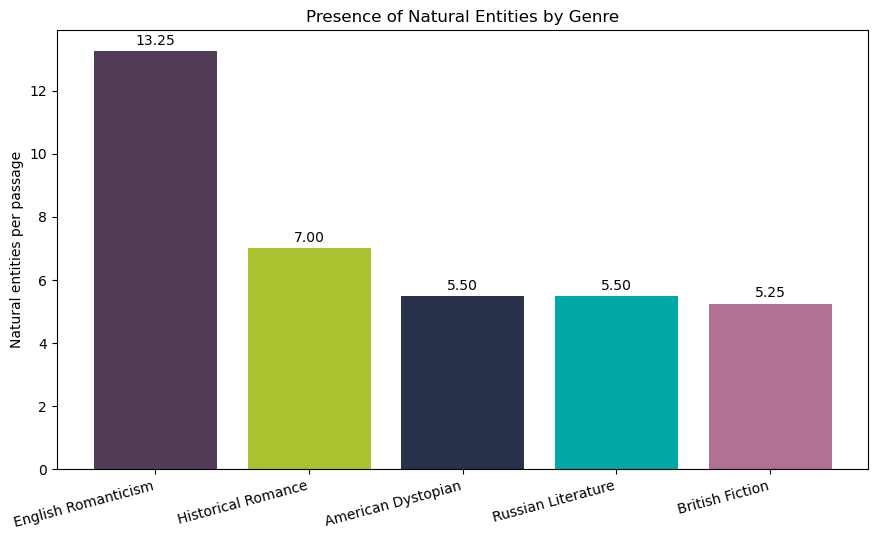

In [51]:
GENRE_COLORS = {
    "english_romanticism": "#513B56",
    "historical_romance":  "#ACC12F",
    "american_dystopian":  "#2A324B",
    "russian_literature":  "#00A9A5",
    "british_fiction":     "#B27092",
}

density_by_genre = {
    genre: genre_entity_counts.get(genre, 0) / genre_passage_counts.get(genre, 1)
    for genre in SCENARIOS
}
genres_sorted = sorted(density_by_genre, key=lambda g: -density_by_genre[g])
values = [density_by_genre[g] for g in genres_sorted]
colors = [GENRE_COLORS[g] for g in genres_sorted]
labels = [g.replace("_", " ").title() for g in genres_sorted]

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.bar(labels, values, color=colors)
ax.set_ylabel("Natural entities per passage")
ax.set_title("Presence of Natural Entities by Genre")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.2, f"{val:.2f}", ha="center")
plt.xticks(rotation=15, ha="right")
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "genre_density.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote genre_density.png")
plt.show()

In [10]:
genre_type_counts = defaultdict(Counter)
for r in llm_results:
    genre_type_counts[r["scenario"]][r["entity_type"]] += 1

header = f"{'Genre':22s}" + "".join(f"{t:>11s}" for t in ENTITY_TYPES) + f"{'Total':>8s}"
print(header)
print("-" * len(header))
for genre in SCENARIOS:
    counts = genre_type_counts[genre]
    total = sum(counts.values())
    row = f"{genre:22s}"
    for t in ENTITY_TYPES:
        pct = 100 * counts.get(t, 0) / total if total else 0
        row += f"{pct:>10.0f}%"
    row += f"{total:>8d}"
    print(row)

genre_composition_path = os.path.join(LLM_DIR, "genre_category_composition.csv")
with open(genre_composition_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["genre"] + ENTITY_TYPES + ["total"])
    for genre in SCENARIOS:
        counts = genre_type_counts[genre]
        total = sum(counts.values())
        row = [genre] + [round(100 * counts.get(t, 0) / total, 1) if total else 0 for t in ENTITY_TYPES] + [total]
        writer.writerow(row)
print("\nWrote genre_category_composition.csv")

Genre                       FLORA      FAUNA    WEATHER  LANDSCAPE     NATURE   Total
-------------------------------------------------------------------------------------
english_romanticism           15%         0%        57%        26%         2%      53
american_dystopian             9%         5%        64%        23%         0%      22
russian_literature             9%         0%        73%        18%         0%      22
historical_romance             4%         4%        75%        18%         0%      28
british_fiction               19%         0%        57%        24%         0%      21

Wrote genre_category_composition.csv


Wrote genre_category_composition.png


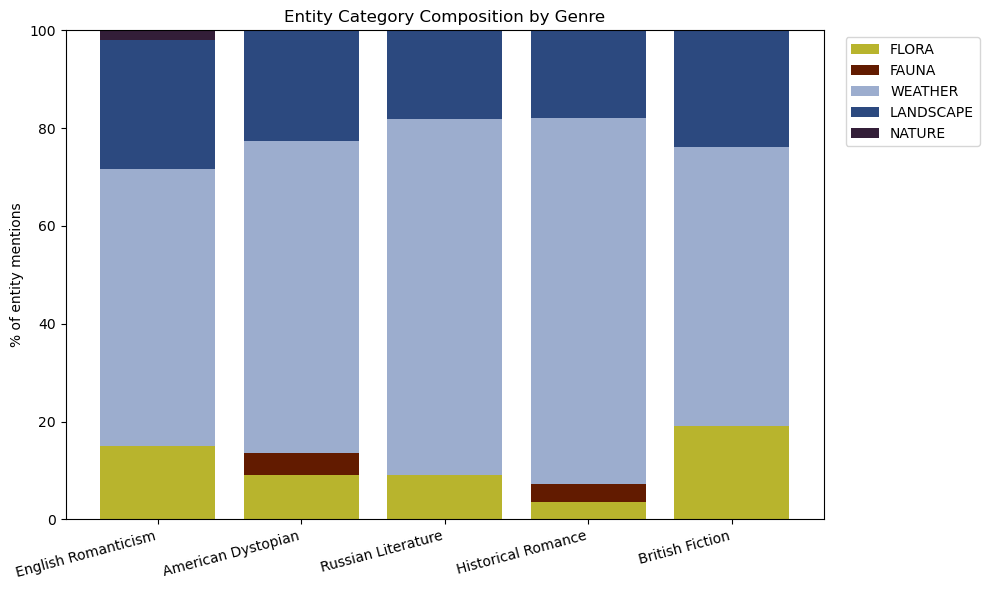

In [ ]:
CATEGORY_COLORS = {
    "WEATHER":   "#9CADCE",
    "LANDSCAPE": "#2C497F",
    "FLORA":     "#B8B42D",
    "FAUNA":     "#621B00",
    "NATURE":    "#331E38",
}

genres = list(SCENARIOS.keys())
labels = [g.replace("_", " ").title() for g in genres]

fig, ax = plt.subplots(figsize=(10, 6))
bottoms = np.zeros(len(genres))
for etype in ENTITY_TYPES:
    pcts = []
    for genre in genres:
        counts = genre_type_counts[genre]
        total = sum(counts.values())
        pcts.append(100 * counts.get(etype, 0) / total if total else 0)
    ax.bar(labels, pcts, bottom=bottoms, label=etype, color=CATEGORY_COLORS[etype])
    bottoms += np.array(pcts)

ax.set_ylabel("% of entity mentions")
ax.set_title("Entity Category Composition by Genre")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.xticks(rotation=15, ha="right")
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "genre_category_composition.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote genre_category_composition.png")
plt.show()

## 1b. Grammatical Agency Across Genres

For the natural entities identified within each genre, this measures how often they function as active grammatical subjects - mirroring the evaluation framework applied to the real corpus.

**Key Findings**:
- First, English Romanticism is not the most grammatically agentive genre. **Russian Literature** narrowly surpasses it in active-subject assignments, despite receiving no explicit style instructions to emphasize agency.
- Contrary to the premise that adventure fiction positions nature as an active physical threat, **Historical Romance** shows the highest reliance on prepositional objects of any genre, while its active-subject rate remains modest rather than exceeding other genres as hypothesized.

In [ ]:
genre_role_counts = defaultdict(Counter)
for r in llm_results:
    genre_role_counts[r["scenario"]][r["role"]] += 1

print(f"{'Genre':22s} {'Total':>6s} {'Active Subj %':>14s} {'Obj of Prep %':>14s}")
for genre in SCENARIOS:
    counts = genre_role_counts.get(genre, Counter())
    total = sum(counts.values())
    if total == 0:
        print(f"{genre:22s}  -- no natural entities generated --")
        continue
    active_pct = 100 * counts.get("Active Subject", 0) / total
    obj_pct = 100 * counts.get("Object of Preposition", 0) / total
    print(f"{genre:22s} {total:>6d} {active_pct:>13.1f}% {obj_pct:>13.1f}%")

genre_role_path = os.path.join(LLM_DIR, "roles_x_genre.csv")
with open(genre_role_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(["genre", "total_entities", "active_subject_pct", "obj_of_prep_pct"])
    for genre in SCENARIOS:
        counts = genre_role_counts.get(genre, Counter())
        total = sum(counts.values())
        active_pct = round(100 * counts.get("Active Subject", 0) / total, 1) if total else None
        obj_pct = round(100 * counts.get("Object of Preposition", 0) / total, 1) if total else None
        writer.writerow([genre, total, active_pct, obj_pct])
print("\nWrote roles_x_genre.csv")

Genre                   Total  Active Subj %  Obj of Prep %
english_romanticism        53          24.5%          49.1%
american_dystopian         22           9.1%          63.6%
russian_literature         22          27.3%          54.5%
historical_romance         28          21.4%          75.0%
british_fiction            21          19.0%          61.9%

Wrote roles_x_genre.csv


Wrote roles_x_genre.png


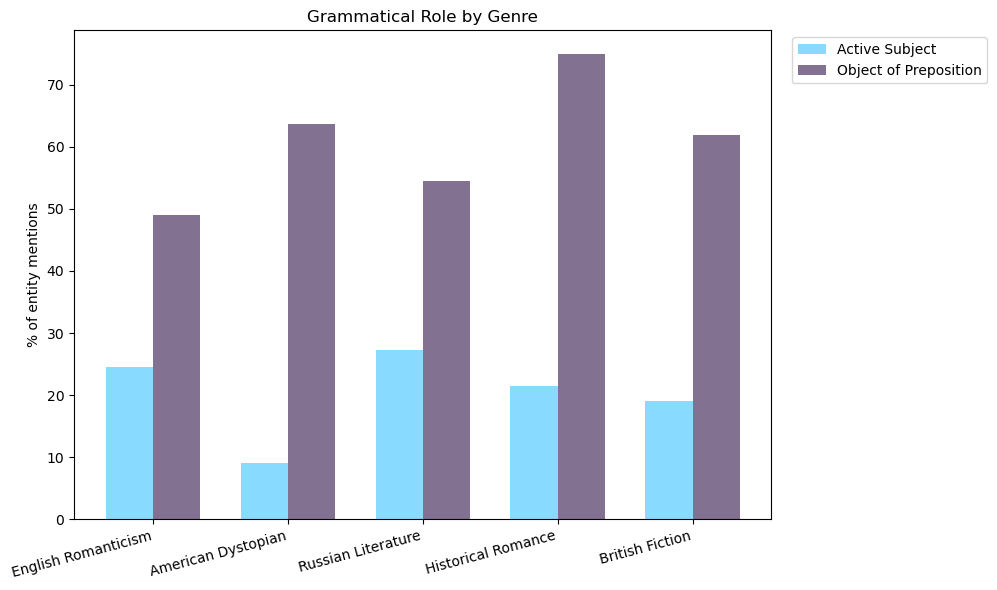

In [ ]:
x = np.arange(len(SCENARIOS))
width = 0.35

genres = list(SCENARIOS.keys())
labels = [g.replace("_", " ").title() for g in genres]
active_vals = [genre_role_counts.get(g, Counter()).get("Active Subject", 0) / sum(genre_role_counts.get(g, Counter()).values()) * 100 if sum(genre_role_counts.get(g, Counter()).values()) else 0 for g in genres]
obj_vals = [genre_role_counts.get(g, Counter()).get("Object of Preposition", 0) / sum(genre_role_counts.get(g, Counter()).values()) * 100 if sum(genre_role_counts.get(g, Counter()).values()) else 0 for g in genres]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, active_vals, width, label="Active Subject", color="#89DAFF")
ax.bar(x + width/2, obj_vals, width, label="Object of Preposition", color="#827191")
ax.set_ylabel("% of entity mentions")
ax.set_title("Grammatical Role by Genre")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "roles_x_genre.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote roles_x_genre.png")
plt.show()

---

# 2. Generated Romanticism Texts vs. the Original Corpus

## 2a. Entity-Type Composition

**Key Findings**:
- **WEATHER** is overrepresented in the generated texts (56.6% of entities, vs. 41.7% in the real corpus) - likely the tradition's single most iconic, most-quoted imagery.
- **LANDSCAPE** is correspondingly underrepresented (26.4% vs. 38.8%), and **FAUNA** is omitted entirely (0.0% vs. 6.0%).

Together, this suggests the model's internalized impression of Romantic nature imagery narrows toward weather and atmosphere, missing the real tradition's fuller ecological range.

In [33]:
REAL_COMPOSITION = {"WEATHER": 41.7, "LANDSCAPE": 38.8, "FLORA": 9.1, "FAUNA": 6.0, "NATURE": 4.3}

romantic_ai_results = [r for r in llm_results if r["scenario"] == "english_romanticism"]
ai_type_counts = Counter(r["entity_type"] for r in romantic_ai_results)
ai_total = sum(ai_type_counts.values())

print(f"{'Type':12s} {'Real Corpus %':>14s} {'AI-Romanticism %':>18s}")
for etype in ENTITY_TYPES:
    real_pct = REAL_COMPOSITION.get(etype, 0)
    ai_pct = 100 * ai_type_counts.get(etype, 0) / ai_total if ai_total else 0
    print(f"{etype:12s} {real_pct:>13.1f}% {ai_pct:>17.1f}%")

if ai_total == 0:
    print("\nNo natural entities were generated under english_romanticism.")

Type          Real Corpus %   AI-Romanticism %
FLORA                  9.1%              15.1%
FAUNA                  6.0%               0.0%
WEATHER               41.7%              56.6%
LANDSCAPE             38.8%              26.4%
NATURE                 4.3%               1.9%


Wrote original_vs_generated_cat.png


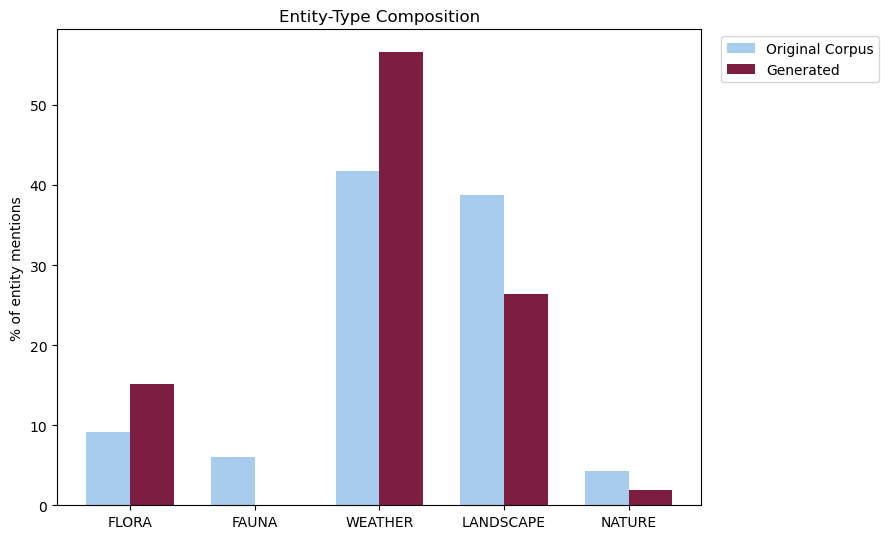

In [ ]:
types = ENTITY_TYPES
real_vals = [REAL_COMPOSITION.get(t, 0) for t in types]
ai_vals = [100 * ai_type_counts.get(t, 0) / ai_total if ai_total else 0 for t in types]

x = np.arange(len(types))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width/2, real_vals, width, label="Original Corpus", color="#A7CCED")
ax.bar(x + width/2, ai_vals, width, label="Generated", color="#7D1D3F")
ax.set_ylabel("% of entity mentions")
ax.set_title("Entity-Type Composition")
ax.set_xticks(x)
ax.set_xticklabels(types)
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "original_vs_generated_cat.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote original_vs_generated_cat.png")
plt.show()

## 2b. Grammatical Role by Entity Type

The real corpus's headline finding is that NATURE shows the highest active-subject rate of all five categories. This checks whether that ranking survives in AI-generated Romantic-style text -- given 2a's finding that NATURE is both rare and diminished here, expect this comparison to rest on very few entities for that category specifically.


**Key Findings**:
- **High-Volume Categories** (WEATHER & FLORA): for categories generated with sufficient sample size, the text closely mirrors the grammatical distribution extracted from the original corpus. WEATHER matches authentic rates almost identically (32.5% vs. 30.0% active subject; 37.3% vs. 36.7% object of preposition). FLORA demonstrates similar alignment (15.1% vs. 25.0% active subject; 48.8% vs. 50.0% object of preposition). This suggests that for categories the model generates in reasonable volume, it reproduces genuine grammatical tendency, not just vocabulary.
- **LANDSCAPE** shows a divergence: in the generated text the object of preposition rate increases to 78.6% (vs. 50.4%), while active subject roles drop to 7.1% (vs. 17.7%) - amplifying the direction of the authentic pattern rather than contradicting it.
- A meaningful comparison is not possible for NATURE and FAUNA: The 100% active subject rate for **NATURE** represents a single observation rather than a true distribution, while **FAUNA** was omitted entirely during generation.

In [49]:
CORPUS_ACTIVE_SUBJECT = {"NATURE": 34.1, "WEATHER": 32.5, "FAUNA": 26.3, "LANDSCAPE": 17.7, "FLORA": 15.1}
CORPUS_OBJ_PREP = {"NATURE": 17.1, "WEATHER": 37.3, "FAUNA": 19.3, "LANDSCAPE": 50.4, "FLORA": 48.8}

romantic_ai_by_type = defaultdict(Counter)
for r in romantic_ai_results:
    romantic_ai_by_type[r["entity_type"]][r["role"]] += 1

print(f"{'Type':10s} {'Corpus Active %':>13s} {'Gen. Active %':>12s} {'Corpus ObjPrep %':>15s} {'Gen. ObjPrep %':>13s} {'Gen. entities':>8s}")
for etype in sorted(CORPUS_ACTIVE_SUBJECT, key=lambda t: -CORPUS_ACTIVE_SUBJECT[t]):
    counts = romantic_ai_by_type[etype]
    total = sum(counts.values())
    if total == 0:
        ai_active_str = ai_prep_str = "n/a"
    else:
        ai_active_str = f"{100 * counts.get('Active Subject', 0) / total:.1f}%"
        ai_prep_str = f"{100 * counts.get('Object of Preposition', 0) / total:.1f}%"
    print(f"{etype:10s} {CORPUS_ACTIVE_SUBJECT[etype]:>12.1f}% {ai_active_str:>12s} {CORPUS_OBJ_PREP[etype]:>14.1f}% {ai_prep_str:>13s} {total:>6d}")

Type       Corpus Active % Gen. Active % Corpus ObjPrep % Gen. ObjPrep % Gen. entities
NATURE             34.1%       100.0%           17.1%          0.0%      1
WEATHER            32.5%        30.0%           37.3%         36.7%     30
FAUNA              26.3%          n/a           19.3%           n/a      0
LANDSCAPE          17.7%         7.1%           50.4%         78.6%     14
FLORA              15.1%        25.0%           48.8%         50.0%      8


Wrote original_generated_roles.png


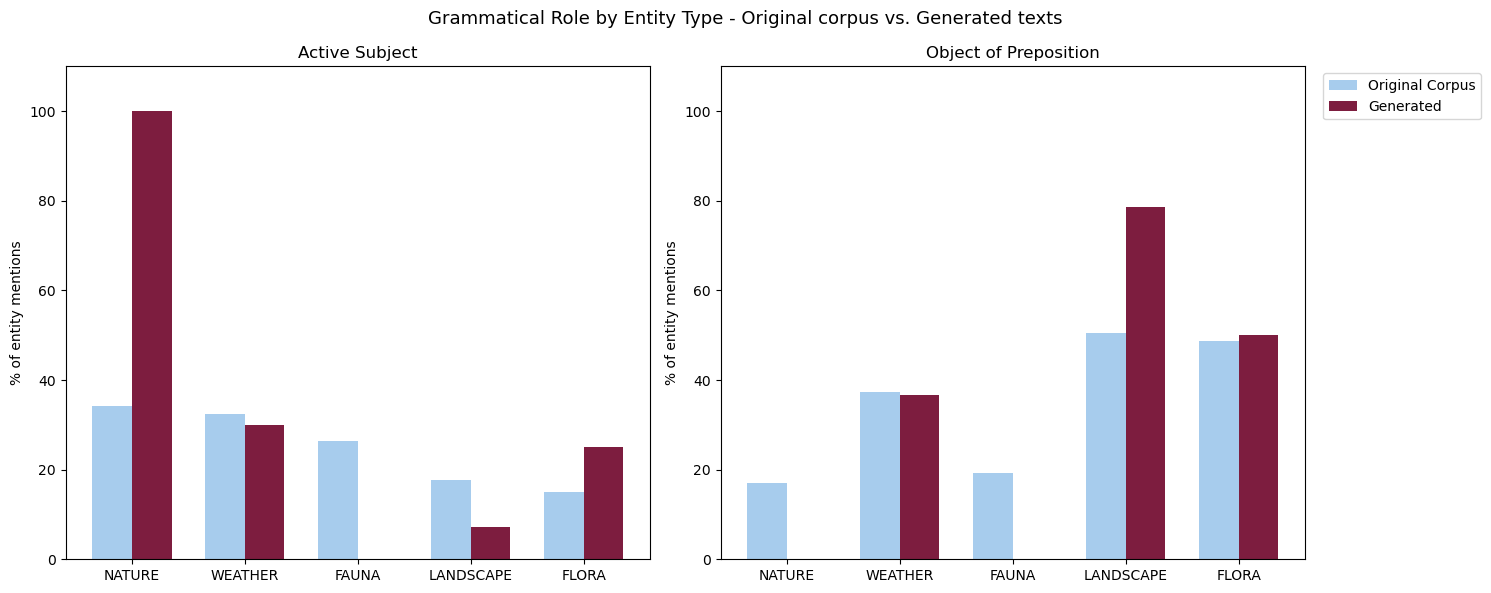

In [50]:
types_ordered = sorted(CORPUS_ACTIVE_SUBJECT, key=lambda t: -CORPUS_ACTIVE_SUBJECT[t])
x = np.arange(len(types_ordered))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, corpus_dict, role_name in [
    (axes[0], CORPUS_ACTIVE_SUBJECT, "Active Subject"),
    (axes[1], CORPUS_OBJ_PREP, "Object of Preposition"),
]:
    corpus_vals = [corpus_dict[t] for t in types_ordered]
    gen_vals, gen_n = [], []
    for t in types_ordered:
        counts = romantic_ai_by_type[t]
        total = sum(counts.values())
        gen_n.append(total)
        gen_vals.append(100 * counts.get(role_name, 0) / total if total else 0)

    ax.bar(x - width/2, corpus_vals, width, label="Original Corpus", color="#A7CCED")
    bars = ax.bar(x + width/2, gen_vals, width, label="Generated", color="#7D1D3F")
    ax.set_title(role_name)
    ax.set_xticks(x)
    ax.set_xticklabels(types_ordered)
    ax.set_ylabel("% of entity mentions")
    ax.set_ylim(0, 110)

axes[1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
fig.suptitle("Grammatical Role by Entity Type - Original corpus vs. Generated texts", fontsize=13)
fig.tight_layout()

chart_path = os.path.join(FIGURES_DIR, "original_generated_roles.png")
fig.savefig(chart_path, dpi=150, bbox_inches="tight")
print("Wrote original_generated_roles.png")
plt.show()